# Pirate Pipeline (V6): The Semantic Context Engine (Full Pillar Update)

**V6 Full Pillar Enhancements:**
1. **Replenishment Heart (Idea 6)**: Added `item_median_repeat_gap` and `ui_replenishment_delta` to capture repurchase cycles.
2. **Persona Diversity (Idea 8)**: Added `user_category_entropy` and `user_brand_hhi` to quantify user behavior.
3. **Economic Drift (Idea 10 & 35)**: Added `item_relative_price` and `user_premium_ratio` for normalized price sensitivity.
4. **Location Context (Idea 21 & 30)**: Added `loc_cat_lift` to anchor local category popularity.
5. **Semantic Matching**: Added `is_primary_category` for specialized user domain boosting.


In [1]:
import polars as pl
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import os, gc, warnings, re, optuna
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [2]:
def standardize_age(text):
    raw_text = str(text).strip()
    clean_text = raw_text.lower()
    if re.search(r'(\*|x\d|cm)', clean_text): return 0.5
    if re.search(r'\bb\d{2}\b', clean_text): return 18.0
    if 's17' in clean_text: return 1.0
    if '110' in clean_text: return 5.0
    if "không xác định" in clean_text or not clean_text: return -1.0
    diaper_map = {r'\bnb\b': 0, r'\bss\b': 0, r'\bsơ sinh\b': 0, r'\bs\b': 0.25, r'\bm\b': 0.6, r'\bl\b': 1.2, r'\bxl\b': 2.0, r'\bxxl\b': 3.5}
    for pattern, val in diaper_map.items():
        if re.search(pattern, clean_text): return float(val)
    range_match = re.search(r'(\d+\.?\d*)\s*-\s*(\d+\.?\d*)', clean_text)
    if range_match:
        s, e = float(range_match.group(1)), float(range_match.group(2))
        avg = (s + e) / 2
        if any(x in clean_text for x in ['m', 'tháng']): return round(avg / 12, 3)
        return avg
    m_match = re.search(r'(\d+\.?\d*)\s*(m|tháng)', clean_text)
    if m_match: return round(float(m_match.group(1)) / 12, 3)
    y_match = re.search(r'(\d+\.?\d*)\s*(y|t|tuổi)', clean_text)
    if y_match: return float(y_match.group(1))
    pure_num = re.search(r'^(\d+)$', clean_text)
    if pure_num:
        val = float(pure_num.group(1))
        if val > 6: return round(val/12, 3)
        else: return val
    return -1.0

def load_and_prep(t_path):
    return pl.scan_parquet(t_path).select([
        pl.col('customer_id').cast(pl.Int32),
        pl.col('item_id').cast(pl.Utf8),
        pl.col('updated_date').cast(pl.Datetime).alias('event_ts'),
        pl.col('quantity').cast(pl.Float32).fill_null(0.0),
        pl.col('event_type').cast(pl.Categorical),
        pl.col('price').cast(pl.Float32).fill_null(0.0),
        pl.col('location').cast(pl.Utf8)
    ]).filter((pl.col('event_type')=='purchased')|(pl.col('quantity')>0)).with_columns(pl.col('event_ts').dt.month().cast(pl.Int8).alias('month')).collect()


In [3]:
T_PATH, I_PATH = '/kaggle/input/datasets/kinonquc/qkindataset2/transaction_full_2025.parquet', '/kaggle/input/datasets/kinonquc/qkindataset2/items.parquet'
if not os.path.exists(T_PATH): T_PATH, I_PATH = '../transaction_full_2025.parquet', '../items.parquet'
df_raw = load_and_prep(T_PATH)
items_df = pl.read_parquet(I_PATH).with_columns(pl.col('item_id').cast(pl.Utf8))
items_df = items_df.with_columns(pl.col('size').map_elements(standardize_age, return_dtype=pl.Float32).alias('item_target_age')) if 'size' in items_df.columns else items_df.with_columns(pl.lit(-1.0).alias('item_target_age'))
cat_cols = ['category_l1', 'category_l2', 'category_l3', 'category', 'brand']
for c in cat_cols:
    items_df = items_df.with_columns([pl.col(c).fill_null('Unk').cast(pl.Categorical).to_physical().cast(pl.Int32).alias(f'{c}_id')])
print(f"    [Loading] Items Columns: {items_df.columns}")
items_df = items_df.with_columns((pl.col('brand') != 'Không xác định').cast(pl.Int32).alias('is_known_brand'))
item_locs = df_raw.group_by('item_id').agg(pl.col('location').unique().alias('item_hubs'))
item_prcs = df_raw.group_by('item_id').agg(pl.col('price').median().alias('item_p'))
df_train_base = df_raw.filter(pl.col('month') <= 10)
df_val_truth  = df_raw.filter(pl.col('month') == 11)
df_train_val_base = df_raw.filter(pl.col('month') <= 11)
df_test_truth = df_raw.filter(pl.col('month') == 12)
del df_raw; gc.collect()


    [Loading] Items Columns: ['item_id', 'price', 'category_l1', 'category_l2', 'category_l3', 'category', 'brand', 'manufacturer', 'description', 'sale_status', 'size', 'item_target_age', 'category_l1_id', 'category_l2_id', 'category_l3_id', 'category_id', 'brand_id']


30

In [4]:
class V5Retriever:
    def __init__(self, history_df, items_df, item_locations, item_prices, target_users):
        print("    [Retriever] Initializing Shielded Interactions...")
        self.history_df, self.item_locations, self.item_prices = history_df, item_locations, item_prices
        hist_sampled = history_df.filter(pl.col('customer_id').is_in(pl.Series("customer_id", target_users)))
        ints = hist_sampled.group_by(['customer_id', 'item_id']).agg(pl.col('quantity').sum().alias('w'))
        ints = ints.with_columns([pl.col('customer_id').rank('dense').cast(pl.Int32).alias('u_idx')-1, pl.col('item_id').rank('dense').cast(pl.Int32).alias('i_idx')-1])
        u_map, i_map = ints.select(['customer_id', 'u_idx']).unique(), ints.select(['item_id', 'i_idx']).unique()
        self.u2idx, self.items_list = dict(zip(u_map['customer_id'], u_map['u_idx'])), i_map.sort('i_idx')['item_id'].to_list()
        print(f"    [Retriever] Building Sparse Matrix ({u_map.height} x {i_map.height})...")
        self.matrix = csr_matrix((ints['w'].to_numpy(), (ints['u_idx'].to_numpy(), ints['i_idx'].to_numpy())), shape=(u_map.height, i_map.height), dtype=np.float32)
        del ints, u_map, i_map; gc.collect()
        print("    [Retriever] Computing I2I & SVD...")
        bin_m = self.matrix.copy(); bin_m.data = np.ones_like(bin_m.data); self.i2i = bin_m.T.dot(bin_m).astype(np.float32); self.i2i.setdiag(0)
        del bin_m; gc.collect()
        svd = TruncatedSVD(n_components=64, random_state=42)
        self.u_f, self.i_f = svd.fit_transform(self.matrix).astype(np.float32), svd.components_.T.astype(np.float32)
        print("    [Retriever] Computing Category Profiles...")
        items_cat = items_df.lazy().select(['item_id', 'category_l1_id']).rename({'category_l1_id': 'cat_id'})
        self.cat_pop = (history_df.lazy().filter(pl.col('month') >= 9).select(['item_id', 'quantity']).join(items_cat, on='item_id', how='left').group_by(['cat_id', 'item_id']).agg(pl.col('quantity').sum().alias('w')).sort('w', descending=True).group_by('cat_id').head(30)).collect()
        self.u_t_cat = (hist_sampled.lazy().select(['customer_id', 'item_id']).join(items_cat, on='item_id', how='left').group_by('customer_id').agg(pl.col('cat_id').mode().first().alias('cat_id'))).collect()
        del hist_sampled; gc.collect()

    def get_candidates(self, target_users, chunk_size=1000):
        print("    [Retriever] Fetching Repurchases...")
        df_rep = self.history_df.filter(pl.col('customer_id').is_in(pl.Series(target_users))).select(['customer_id', 'item_id']).unique()
        c_i2i, c_svd, i_arr = [], [], np.array(self.items_list)
        t_idx = [self.u2idx[u] for u in target_users if u in self.u2idx]
        t_u = [u for u in target_users if u in self.u2idx]
        for i in range(0, len(t_idx), chunk_size):
            idx, u = t_idx[i:i+chunk_size], np.array(t_u[i:i+chunk_size])
            s_i = self.matrix[idx].dot(self.i2i).toarray(); t40 = np.argsort(-s_i, axis=1)[:, :40]; m = np.take_along_axis(s_i, t40, axis=1) > 0
            c_i2i.append(pl.DataFrame({'customer_id': np.repeat(u, 40)[m.flatten()], 'item_id': i_arr[t40.flatten()][m.flatten()]}, schema={'customer_id': pl.Int32, 'item_id': pl.Utf8}))
            s_s = self.u_f[idx] @ self.i_f.T; t50 = np.argsort(-s_s, axis=1)[:, :50]
            c_svd.append(pl.DataFrame({'customer_id': np.repeat(u, 50), 'item_id': i_arr[t50.flatten()]}, schema={'customer_id': pl.Int32, 'item_id': pl.Utf8}))
            del s_i, s_s, m, t40, t50; gc.collect()
        df_i2i, df_svd = pl.concat(c_i2i).unique() if c_i2i else pl.DataFrame(), pl.concat(c_svd).unique() if c_svd else pl.DataFrame()
        df_cat = self.u_t_cat.filter(pl.col('customer_id').is_in(target_users)).join(self.cat_pop, on='cat_id').select(['customer_id', 'item_id'])
        return {'rep': df_rep, 'i2i': df_i2i, 'svd': df_svd, 'cat': df_cat}

    def filter_candidates(self, cands_dict, target_users):
        all_cands = pl.concat([df for df in cands_dict.values() if df.height > 0]).unique()
        hist_s = self.history_df.filter(pl.col('customer_id').is_in(pl.Series("customer_id", target_users)))
        uh = hist_s.group_by('customer_id').agg(pl.col('location').mode().first().alias('loc'))
        up = hist_s.group_by('customer_id').agg(pl.col('price').mean().alias('avg_p'))
        del hist_s; gc.collect()
        f = (all_cands.join(up, on='customer_id', how='left').join(self.item_prices, on='item_id', how='left').filter((pl.col('item_p') <= pl.col('avg_p') * 6) | (pl.col('avg_p') == 0)).select(['customer_id', 'item_id']))
        item_loc_flat = self.item_locations.explode('item_hubs').rename({'item_hubs': 'loc'})
        f = (f.join(uh, on='customer_id', how='left').join(item_loc_flat, on=['item_id', 'loc'], how='inner').select(['customer_id', 'item_id']))
        del uh, item_loc_flat; gc.collect()
        return f


In [5]:
def create_dataset_v6(history_df, truth_df, items_df, item_locations, item_prices, sample_users=50000, n_negatives=30):
    target_users = truth_df['customer_id'].unique().to_list()
    if sample_users and sample_users < len(target_users): 
        target_users = list(np.random.choice(target_users, sample_users, replace=False))
        truth_df = truth_df.filter(pl.col('customer_id').is_in(target_users))
    retriever = V5Retriever(history_df, items_df, item_locations, item_prices, target_users)
    cands_dict = retriever.get_candidates(target_users)
    filtered_cands = retriever.filter_candidates(cands_dict, target_users)
    truth = truth_df.select(['customer_id', 'item_id']).unique()
    ds = filtered_cands.join(truth.with_columns(pl.lit(1).cast(pl.Int8).alias('target')), on=['customer_id', 'item_id'], how='left').fill_null(0)
    if n_negatives:
        pos, neg = ds.filter(pl.col('target') == 1), ds.filter(pl.col('target') == 0).with_columns(pl.int_range(0, pl.len()).shuffle(seed=42).alias("_rand")).sort(["customer_id", "_rand"]).group_by("customer_id").head(n_negatives).drop("_rand")
        ds = pl.concat([pos, neg])
    
    max_ts = history_df['event_ts'].max()
    hist_lazy = history_df.lazy()
    
    print("    [Dataset] Computing Advanced Global Item Features (Streaming)... ")
    # Item Stats + Repeat Gap
    gaps_df = (hist_lazy.sort(['customer_id', 'item_id', 'event_ts'])
        .select(['customer_id', 'item_id', 'event_ts'])
        .with_columns(gap = pl.col('event_ts').diff().over(['customer_id', 'item_id']).dt.total_days())
        .filter(pl.col('gap').is_not_null())
        .group_by('item_id').agg(pl.col('gap').median().alias('item_median_repeat_gap'))
    ).collect()
    
    item_feats_df = hist_lazy.group_by('item_id').agg([
        pl.col('quantity').sum().alias('item_global_vol'),
        pl.col('customer_id').n_unique().alias('item_unique_buyers'),
        (pl.col('customer_id').len() / pl.col('customer_id').n_unique()).alias('item_repeat_propensity'),
        pl.col('event_ts').filter(pl.col('event_ts') >= max_ts - pl.duration(days=30)).len().alias('vol_30d'),
        pl.col('event_ts').filter((pl.col('event_ts') < max_ts - pl.duration(days=30)) & (pl.col('event_ts') >= max_ts - pl.duration(days=60))).len().alias('vol_60d'),
        (max_ts - pl.col('event_ts').min()).dt.total_days().cast(pl.Int16).alias('item_launch_age_days')
    ]).with_columns([
        (pl.col('vol_30d') / (pl.col('vol_60d') + 1)).cast(pl.Float32).alias('item_30d_momentum')
    ]).drop(['vol_30d', 'vol_60d']).collect().join(gaps_df, on='item_id', how='left')

    print("    [Dataset] Computing Category Momentum & Prices... ")
    cat_mom = hist_lazy.join(items_df.lazy().select(['item_id', 'category_l1_id']), on='item_id').group_by('category_l1_id').agg([
        pl.col('event_ts').filter(pl.col('event_ts') >= max_ts - pl.duration(days=30)).len().alias('c_vol_30d'),
        pl.col('event_ts').filter((pl.col('event_ts') < max_ts - pl.duration(days=30)) & (pl.col('event_ts') >= max_ts - pl.duration(days=60))).len().alias('c_vol_60d'),
    ]).with_columns([
        (pl.col('c_vol_30d') / (pl.col('c_vol_60d') + 1)).cast(pl.Float32).alias('category_30d_momentum')
    ]).drop(['c_vol_30d', 'c_vol_60d']).collect()

    cat_price = item_prices.join(items_df.select(['item_id', 'category_l1_id']), on='item_id').group_by('category_l1_id').agg(pl.col('item_p').median().alias('cat_median_p'))
    item_prices_ext = item_prices.join(items_df.select(['item_id', 'category_l1_id']), on='item_id').join(cat_price, on='category_l1_id').with_columns((pl.col('item_p') / (pl.col('cat_median_p') + 1)).cast(pl.Float32).alias('item_relative_price'))
    
    # Location Category Lift (Idea 21)
    print("    [Dataset] Computing Location Context...")
    loc_stats = history_df.join(items_df.select(['item_id', 'category_l1_id']), on='item_id')
    g_cat_share = loc_stats.group_by('category_l1_id').len().with_columns(g_share = pl.col('len') / pl.col('len').sum())
    l_cat_share = loc_stats.group_by(['location', 'category_l1_id']).len().with_columns(l_share = pl.col('len') / pl.col('len').sum().over('location'))
    loc_cat_lift = l_cat_share.join(g_cat_share.select(['category_l1_id', 'g_share']), on='category_l1_id').with_columns((pl.col('l_share') / pl.col('g_share')).alias('loc_cat_lift'))

    print("    [Dataset] Computing User & UI Features...")
    hist_s = history_df.filter(pl.col('customer_id').is_in(pl.Series("customer_id", target_users))).join(items_df.select(['item_id', 'category_l1_id', 'brand_id', 'item_target_age']), on='item_id', how='left')
    
    user_feats_df = hist_s.group_by('customer_id').agg([
        pl.col('item_id').n_unique().alias('user_unique_items'),
        pl.col('category_l1_id').n_unique().alias('user_unique_categories'),
        pl.col('quantity').sum().alias('user_total_volume'),
        pl.col('price').mean().alias('user_avg_price'),
        pl.col('item_target_age').max().alias('user_max_target_age'),
        (max_ts - pl.col('event_ts').min()).dt.total_days().cast(pl.Int16).alias('user_tenure_days')
    ])
    # Advanced User Diversity (Entropy/HHI)
    u_cat_ent = hist_s.group_by(['customer_id', 'category_l1_id']).len().with_columns(p = pl.col('len')/pl.col('len').sum().over('customer_id')).group_by('customer_id').agg((-pl.col('p') * pl.col('p').log()).sum().alias('user_category_entropy'))
    u_brd_hhi = hist_s.group_by(['customer_id', 'brand_id']).len().with_columns(p = pl.col('len')/pl.col('len').sum().over('customer_id')).group_by('customer_id').agg((pl.col('p')**2).sum().alias('user_brand_hhi'))
    # User Premium Ratio (Idea 35)
    u_prem = hist_s.join(item_prices_ext.select(['item_id', 'item_relative_price']), on='item_id').group_by('customer_id').agg(((pl.col('item_relative_price') > 1.2).sum() / pl.len()).alias('user_premium_ratio'))
    
    user_feats_df = user_feats_df.join(u_cat_ent, on='customer_id', how='left').join(u_brd_hhi, on='customer_id', how='left').join(u_prem, on='customer_id', how='left')
    user_feats_df = user_feats_df.with_columns([
        (pl.col('user_unique_categories') / (pl.col('user_total_volume')+1)).cast(pl.Float32).alias('user_category_breadth'),
        (pl.col('user_total_volume') / (pl.col('user_tenure_days') / 30 + 1)).cast(pl.Float32).alias('user_txn_velocity')
    ])
    u_prim_cat = hist_s.group_by('customer_id').agg(pl.col('category_l1_id').mode().first().alias('user_primary_cat_l1'), pl.col('location').mode().first().alias('user_primary_loc'))
    user_feats_df = user_feats_df.join(u_prim_cat, on='customer_id', how='left')

    ui_f = hist_s.join(ds.select(['customer_id', 'item_id']), on=['customer_id', 'item_id'], how='inner').group_by(['customer_id', 'item_id']).agg([
        pl.col('quantity').sum().alias('ui_buy_vol'),
        (max_ts - pl.col('event_ts').max()).dt.total_days().cast(pl.Int16).alias('ui_days_since_last_buy')
    ])
    del hist_s; gc.collect()
    
    print("    [Dataset] Executing Final Streaming Join...")
    # Note: We compute item_age_delta directly in the final join
    final_ds = (ds.lazy()
        .join(user_feats_df.lazy(), on='customer_id', how='left')
        .join(item_feats_df.lazy(), on='item_id', how='left')
        .join(ui_f.lazy(), on=['customer_id', 'item_id'], how='left')
        .join(items_df.lazy().select(['item_id', 'category_l1_id', 'category_l2_id', 'category_l3_id', 'category_id', 'brand_id', 'item_target_age', 'is_known_brand']).unique(subset=['item_id']), on='item_id', how='left')
        .join(cat_mom.lazy(), on='category_l1_id', how='left')
        .join(item_prices_ext.lazy().select(['item_id', 'item_relative_price']), on='item_id', how='left')
        .join(loc_cat_lift.lazy().select(['location', 'category_l1_id', 'loc_cat_lift']), left_on=['user_primary_loc', 'category_l1_id'], right_on=['location', 'category_l1_id'], how='left')
        .with_columns([
            (pl.col('item_target_age') - pl.col('user_max_target_age')).cast(pl.Float32).alias('item_age_delta'),
            (pl.col('category_l1_id') == pl.col('user_primary_cat_l1')).cast(pl.Int32).alias('is_primary_category'),
            (pl.col('ui_days_since_last_buy') - pl.col('item_median_repeat_gap')).abs().alias('ui_replenishment_delta')
        ])
        .fill_null(0)
    ).collect(streaming=True)
    return final_ds

print("=== BUILDING DATASETS ===")
train_data = create_dataset_v6(df_train_base, df_val_truth, items_df, item_locs, item_prcs, sample_users=50000)
test_data = create_dataset_v6(df_train_val_base, df_test_truth, items_df, item_locs, item_prcs, sample_users=20000, n_negatives=None)


=== BUILDING DATASETS ===
    [Retriever] Initializing Shielded Interactions...
    [Retriever] Building Sparse Matrix (38322 x 12059)...
    [Retriever] Computing I2I & SVD...
    [Retriever] Computing Category Profiles...
    [Retriever] Fetching Repurchases...
    [Dataset] Computing Advanced Global Item Features (Streaming)... 
    [Dataset] Computing Category Momentum & Prices... 
    [Dataset] Computing Location Context...
    [Dataset] Computing User & UI Features...
    [Dataset] Executing Final Streaming Join...
    [Retriever] Initializing Shielded Interactions...
    [Retriever] Building Sparse Matrix (15276 x 10381)...
    [Retriever] Computing I2I & SVD...
    [Retriever] Computing Category Profiles...
    [Retriever] Fetching Repurchases...
    [Dataset] Computing Advanced Global Item Features (Streaming)... 
    [Dataset] Computing Category Momentum & Prices... 
    [Dataset] Computing Location Context...
    [Dataset] Computing User & UI Features...
    [Dataset] Execut

In [6]:
feature_cols = [
    'item_global_vol', 'item_unique_buyers', 'item_repeat_propensity', 'item_30d_momentum', 'item_launch_age_days', 'item_median_repeat_gap',
    'user_unique_items', 'user_unique_categories', 'user_total_volume', 'user_avg_price', 'user_tenure_days', 'user_category_breadth', 'user_txn_velocity', 'user_max_target_age', 
    'user_category_entropy', 'user_brand_hhi', 'user_premium_ratio',
    'ui_buy_vol', 'ui_days_since_last_buy', 'ui_replenishment_delta',
    'item_target_age', 'item_age_delta',
    'is_known_brand', 'is_primary_category', 'category_30d_momentum', 'item_relative_price', 'loc_cat_lift'
]
cat_feats = ['category_l1_id', 'category_l2_id', 'category_l3_id', 'category_id', 'brand_id']
all_feats = feature_cols + cat_feats

u_tune = train_data['customer_id'].unique().to_list()
u_trn_idx = int(len(u_tune)*0.8)
u_trn, u_val = u_tune[:u_trn_idx], u_tune[u_trn_idx:]
d_trn, d_val = train_data.filter(pl.col('customer_id').is_in(u_trn)), train_data.filter(pl.col('customer_id').is_in(u_val))

def objective(trial):
    params = {
        'objective': 'binary', 
        'metric': 'binary_logloss', 
        'verbosity': -1, 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), 
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9)
    }
    
    trn_set = lgb.Dataset(d_trn.select(all_feats).to_numpy(), label=d_trn['target'].to_numpy(), feature_name=all_feats, categorical_feature=cat_feats)
    val_set = lgb.Dataset(d_val.select(all_feats).to_numpy(), label=d_val['target'].to_numpy(), feature_name=all_feats, categorical_feature=cat_feats, reference=trn_set)
    
    m = lgb.train(params, trn_set, num_boost_round=3000, valid_sets=[val_set], valid_names=['valid'], callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    return m.best_score['valid']['binary_logloss']

print("Running Dtype-Safe Optuna Tuning...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=12)
best_params = study.best_params; best_params.update({'objective': 'binary', 'metric': 'binary_logloss'})
print("Best Params (Safe):", best_params)


Running Dtype-Safe Optuna Tuning...
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2350]	valid's binary_logloss: 0.134911
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[352]	valid's binary_logloss: 0.135077
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[336]	valid's binary_logloss: 0.134534
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[217]	valid's binary_logloss: 0.135354
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[549]	valid's binary_logloss: 0.135047
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[486]	valid's binary_logloss: 0.135051
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[212]	valid's binary_logloss: 0.134949
Training until val

Training Final Models...


<Figure size 1000x600 with 0 Axes>

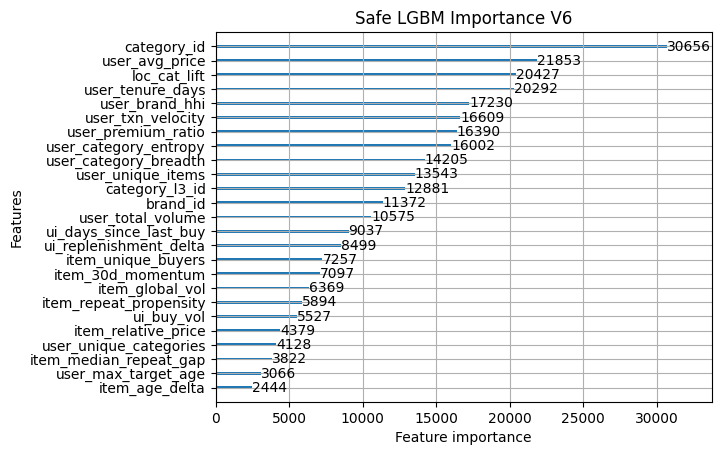

In [7]:
print("Training Final Models...")
lgb_m = lgb.train(best_params, 
                  lgb.Dataset(train_data.select(all_feats).to_numpy(), 
                              label=train_data['target'].to_numpy(), 
                              feature_name=all_feats, 
                              categorical_feature=cat_feats), 
                  num_boost_round=2000)

xgb_m = xgb.XGBClassifier(n_estimators=2000, learning_rate=best_params.get('learning_rate', 0.02), max_depth=best_params.get('max_depth', 8), enable_categorical=True).fit(train_data.select(all_feats).to_numpy(), train_data['target'].to_numpy())

train_pool = Pool(train_data.select(all_feats), label=train_data['target'], cat_features=cat_feats)
cb_m = CatBoostClassifier(iterations=2000, depth=best_params.get('max_depth', 8), verbose=0).fit(train_pool)

plt.figure(figsize=(10, 6)); lgb.plot_importance(lgb_m, max_num_features=25, title='Safe LGBM Importance V6'); plt.show()


In [8]:
test_data = test_data.with_columns([pl.Series(name='pred_lgb', values=lgb_m.predict(test_data.select(all_feats))), pl.Series(name='pred_xgb', values=xgb_m.predict_proba(test_data.select(all_feats).to_numpy())[:, 1]), pl.Series(name='pred_cb', values=cb_m.predict_proba(test_data.select(all_feats))[:, 1])])
def evaluate_model(model_col):
    top10 = test_data.sort(['customer_id', model_col], descending=[False, True]).group_by('customer_id', maintain_order=True).head(10)
    truth_map = df_test_truth.filter(pl.col('customer_id').is_in(top10['customer_id'].unique().to_list())).group_by('customer_id').agg(pl.col('item_id'))
    truth_dict, pred_dict = {row[0]: set(row[1]) for row in truth_map.iter_rows()}, {row[0]: list(row[1]) for row in top10.group_by('customer_id').agg(pl.col('item_id')).iter_rows()}
    h, m, p = 0, 0.0, 0.0
    for uid, truth in truth_dict.items():
        preds = pred_dict.get(uid, [])
        hits = [pr for pr in preds if pr in truth]
        h += len(hits); p += len(hits)/10.0
        for i, pr in enumerate(preds):
            if pr in truth: m += 1.0/(i+1); break
    return {'Hits': h, 'Precision@10': p/max(1,len(truth_dict)), 'MRR': m/max(1,len(truth_dict))}
print("=== Safe LGBM V6 ==="); print(evaluate_model('pred_lgb'))
print("=== Safe XGBoost V6 ==="); print(evaluate_model('pred_xgb'))
print("=== Safe CatBoost V6 ==="); print(evaluate_model('pred_cb'))


=== Safe LGBM V6 ===
{'Hits': 16753, 'Precision@10': 0.1096687614558723, 'MRR': 0.46126775271511744}
=== Safe XGBoost V6 ===
{'Hits': 16436, 'Precision@10': 0.10759361089289848, 'MRR': 0.45350217375943763}
=== Safe CatBoost V6 ===
{'Hits': 16044, 'Precision@10': 0.10502749410840025, 'MRR': 0.439327199632576}
